# Grupo  11 : Lucas Muniz Miranda e Thiago Matehus, tema : Análise de preços de combustíveis

In [1]:
!pip install plotly openpyxl --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Bibliotecas importadas!')

✅ Bibliotecas importadas!


In [3]:
df = pd.read_csv('simulacao_precos_combustiveis_brasil.csv')

print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
df.head()

Linhas: 4440 | Colunas: 14


,ano,mes,data,regiao,uf,combustivel,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Gasolina,7.49,6.90,8.47,6.75,2.89,78.31,179221,Médio
1,2015,1,2015-01-01,Norte,PA,Diesel,3.80,3.50,4.30,1.67,10.94,95.35,50575,Alto
2,2015,1,2015-01-01,Norte,PA,GNV,4.83,4.45,5.46,-2.85,2.60,47.82,171715,Médio
3,2015,1,2015-01-01,Norte,RO,Gasolina,7.14,6.57,8.07,-4.83,6.99,95.94,195652,Crítico
4,2015,1,2015-01-01,Norte,TO,Diesel,3.30,3.03,3.73,6.30,3.02,45.92,49432,Médio


## 🧹 4. Limpeza e Preparação dos Dados

Etapas realizadas:
- Conversão da coluna `data` para o tipo datetime
- Validação e conversão das colunas numéricas
- Remoção de duplicatas
- Remoção de linhas com preço inválido (zero ou nulo)
- **Engenharia de atributos:** criação de `trimestre`, `ano_mes` e `amplitude_preco`





In [4]:
df['data'] = pd.to_datetime(df['data'])

cols_num = ['preco_medio', 'preco_minimo', 'preco_maximo',
            'variacao_mensal', 'inflacao', 'cotacao_petroleo', 'consumo_estimado']
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')

antes = len(df)
df = df.drop_duplicates()
print(f'Duplicatas removidas: {antes - len(df)}')

df = df[df['preco_medio'] > 0]

df['trimestre'] = df['data'].dt.quarter
df['ano_mes']   = df['data'].dt.to_period('M').astype(str)
df['amplitude_preco'] = df['preco_maximo'] - df['preco_minimo']

print(f'✅ Dataset pronto: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.dtypes

Duplicatas removidas: 0
✅ Dataset pronto: 4440 linhas × 17 colunas


,0
ano,int64
mes,int64
data,datetime64[ns]
regiao,object
uf,object
combustivel,object
preco_medio,float64
preco_minimo,float64
preco_maximo,float64
variacao_mensal,float64


## 🔍 5. Verificação Geral dos Dados

Checagem de valores nulos e estatísticas descritivas para garantir a qualidade do dataset antes das análises.



In [5]:
print('=== Valores nulos ===')
print(df.isnull().sum())
print()
print('=== Estatísticas descritivas ===')
df.describe().round(2)

=== Valores nulos ===
ano                 0
mes                 0
data                0
regiao              0
uf                  0
combustivel         0
preco_medio         0
preco_minimo        0
preco_maximo        0
variacao_mensal     0
inflacao            0
cotacao_petroleo    0
consumo_estimado    0
nivel_preco         0
trimestre           0
ano_mes             0
amplitude_preco     0
dtype: int64

=== Estatísticas descritivas ===


,ano,mes,data,preco_medio,preco_minimo,preco_maximo,variacao_mensal,inflacao,cotacao_petroleo,consumo_estimado,trimestre,amplitude_preco
count,4440.00,4440.00,4440,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00,4440.00
mean,2019.50,6.50,2019-12-16 10:48:00,5.51,5.07,6.23,0.51,7.02,77.40,126397.95,2.50,1.16
min,2015.00,1.00,2015-01-01 00:00:00,3.00,2.76,3.39,-15.61,2.00,45.01,5013.00,1.00,0.63
25%,2017.00,3.75,2017-06-23 12:00:00,4.24,3.90,4.79,-2.13,4.51,61.10,63811.50,1.75,0.89
50%,2019.50,6.50,2019-12-16 12:00:00,5.53,5.08,6.24,0.50,7.01,77.76,125770.00,2.50,1.16
75%,2022.00,9.25,2022-06-08 12:00:00,6.78,6.24,7.66,3.21,9.48,93.52,187888.50,3.25,1.42
max,2024.00,12.00,2024-12-01 00:00:00,8.00,7.36,9.04,14.73,12.00,109.98,249977.00,4.00,1.68
std,2.87,3.45,NaN,1.46,1.34,1.65,4.02,2.88,18.87,71390.34,1.12,0.31


## 📊 6. KPIs — Indicadores-Chave de Desempenho

Cálculo dos principais indicadores para o painel executivo:
- Preço médio nacional
- Combustível mais caro
- Estado com maior preço médio
- Maior variação mensal registrada
- Consumo estimado total
- Região mais cara

In [6]:
preco_medio_nacional  = df['preco_medio'].mean()
combustivel_mais_caro = df.groupby('combustivel')['preco_medio'].mean().idxmax()
preco_comb_mais_caro  = df.groupby('combustivel')['preco_medio'].mean().max()
estado_mais_caro      = df.groupby('uf')['preco_medio'].mean().idxmax()
preco_estado_caro     = df.groupby('uf')['preco_medio'].mean().max()
maior_variacao_row    = df.loc[df['variacao_mensal'].abs().idxmax()]
consumo_total         = df['consumo_estimado'].sum()
regiao_mais_cara      = df.groupby('regiao')['preco_medio'].mean().idxmax()

print('=' * 55)
print('          📊  KPIs — PAINEL EXECUTIVO')
print('=' * 55)
print(f'  💰 Preço médio nacional      : R$ {preco_medio_nacional:.2f}')
print(f'  🔥 Combustível mais caro     : {combustivel_mais_caro} (R$ {preco_comb_mais_caro:.2f})')
print(f'  📍 Estado com maior preço    : {estado_mais_caro} (R$ {preco_estado_caro:.2f})')
print(f'  📈 Maior variação mensal     : {maior_variacao_row["variacao_mensal"]:.2f}% '
      f'({maior_variacao_row["combustivel"]} - {maior_variacao_row["uf"]} - {maior_variacao_row["ano"]})')
print(f'  ⛽ Consumo estimado total    : {consumo_total:,.0f} litros')
print(f'  🗺️  Região mais cara          : {regiao_mais_cara}')
print('=' * 55)

          📊  KPIs — PAINEL EXECUTIVO
  💰 Preço médio nacional      : R$ 5.51
  🔥 Combustível mais caro     : Etanol (R$ 5.56)
  📍 Estado com maior preço    : CE (R$ 5.68)
  📈 Maior variação mensal     : -15.61% (Gasolina - MS - 2023)
  ⛽ Consumo estimado total    : 561,206,904 litros
  🗺️  Região mais cara          : Nordeste


## 📈 7. Visualização 1 — Linha Temporal: Evolução dos Preços

Evolução do preço médio ao longo dos anos (2015–2024), separado por tipo de combustível.
Permite identificar tendências, picos e períodos de instabilidade.


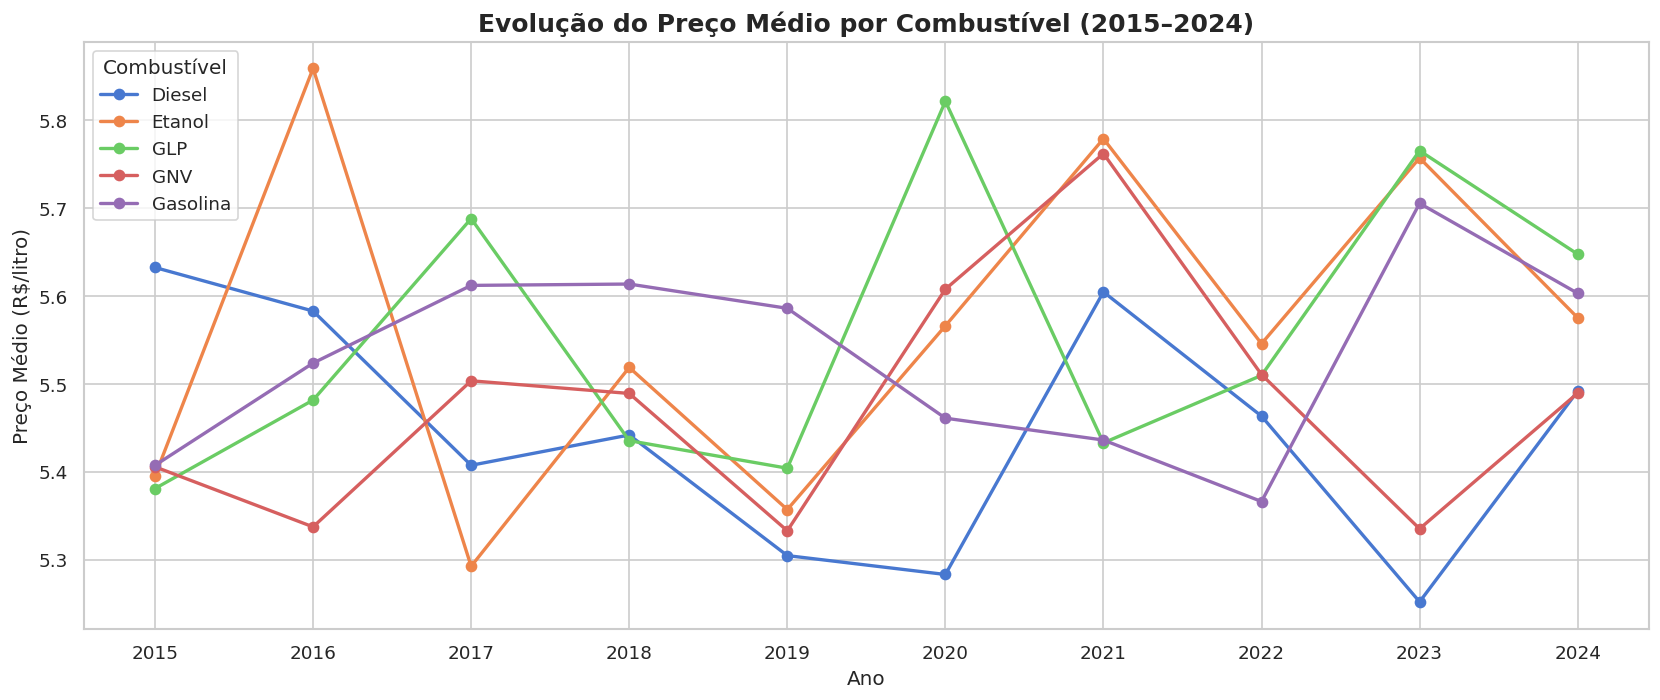

✅ Gráfico salvo como grafico_linha_temporal.png


In [7]:
evolucao = df.groupby(['ano', 'combustivel'])['preco_medio'].mean().reset_index()

plt.figure(figsize=(14, 6))
for combustivel in evolucao['combustivel'].unique():
    dados = evolucao[evolucao['combustivel'] == combustivel]
    plt.plot(dados['ano'], dados['preco_medio'], marker='o', linewidth=2, label=combustivel)

plt.title('Evolução do Preço Médio por Combustível (2015–2024)', fontsize=15, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Preço Médio (R$/litro)')
plt.xticks(evolucao['ano'].unique())
plt.legend(title='Combustível')
plt.tight_layout()
plt.savefig('grafico_linha_temporal.png', dpi=150)
plt.show()
print('✅ Gráfico salvo como grafico_linha_temporal.png')

## 🗺️ 8. Visualização 2 — Barras por Estado: Comparação Regional

Comparação do preço médio entre os estados brasileiros presentes no dataset.
Permite identificar quais estados possuem os combustíveis mais caros e mais baratos.



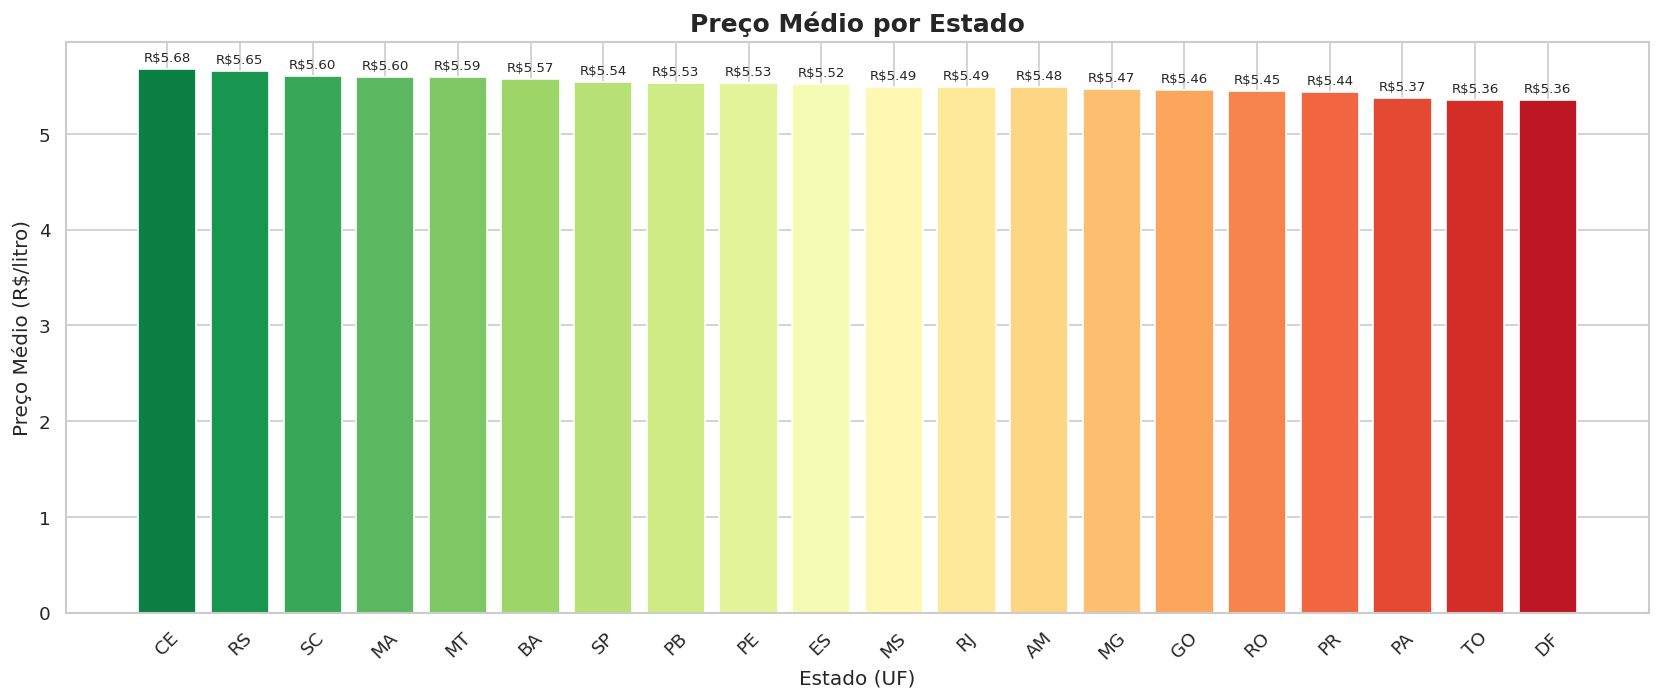

✅ Gráfico salvo como grafico_barras_estado.png


In [8]:
preco_estado = df.groupby('uf')['preco_medio'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))
bars = plt.bar(preco_estado['uf'], preco_estado['preco_medio'],
               color=sns.color_palette('RdYlGn_r', len(preco_estado)))

# Adiciona o valor em cima de cada barra
for bar, valor in zip(bars, preco_estado['preco_medio']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'R${valor:.2f}',
             ha='center', va='bottom', fontsize=8)

plt.title('Preço Médio por Estado', fontsize=15, fontweight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Preço Médio (R$/litro)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_barras_estado.png', dpi=150)
plt.show()
print('✅ Gráfico salvo como grafico_barras_estado.png')

## ⛽ 9. Visualização 3 — Barras por Combustível: Comparação Energética

Comparação do preço médio entre os diferentes tipos de combustível.
Permite identificar qual combustível é mais caro e qual apresentou maior variação ao longo do período.

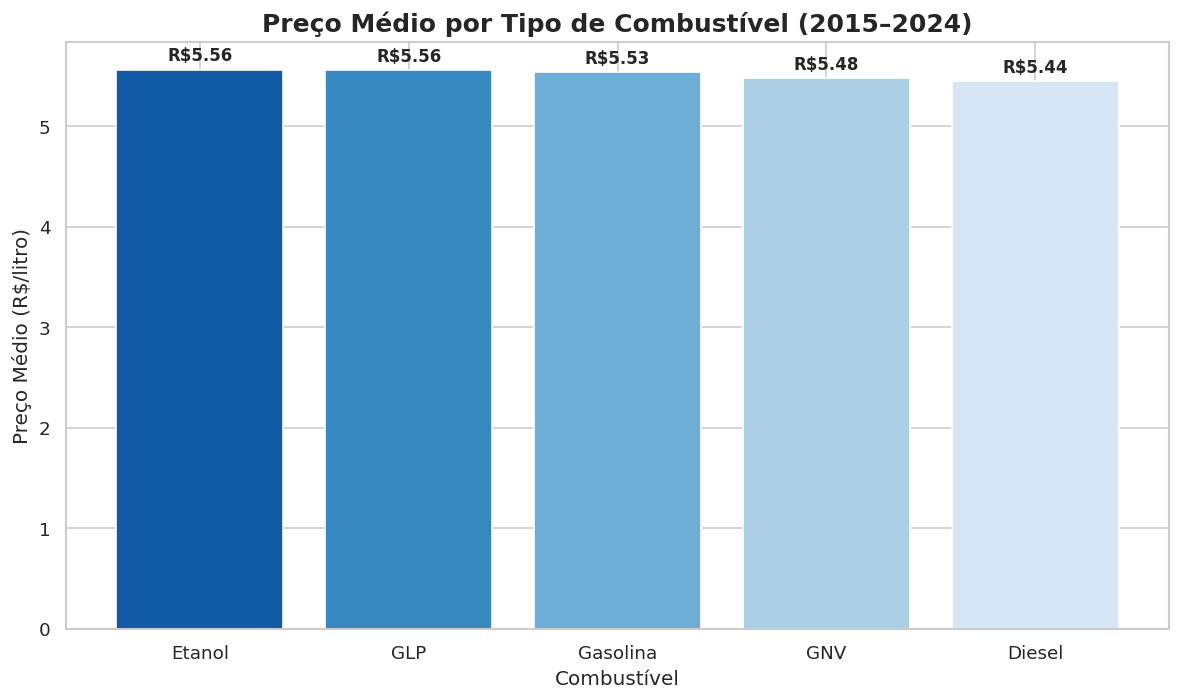

✅ Gráfico salvo como grafico_barras_combustivel.png


In [9]:
preco_combustivel = df.groupby('combustivel')['preco_medio'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(preco_combustivel['combustivel'], preco_combustivel['preco_medio'],
               color=sns.color_palette('Blues_r', len(preco_combustivel)))

# Adiciona o valor em cima de cada barra
for bar, valor in zip(bars, preco_combustivel['preco_medio']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'R${valor:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Preço Médio por Tipo de Combustível (2015–2024)', fontsize=15, fontweight='bold')
plt.xlabel('Combustível')
plt.ylabel('Preço Médio (R$/litro)')
plt.tight_layout()
plt.savefig('grafico_barras_combustivel.png', dpi=150)
plt.show()
print('✅ Gráfico salvo como grafico_barras_combustivel.png')

## 🔥 10. Visualização 4 — Heatmap Mensal: Evolução Temporal

Mapa de calor com o preço médio por mês e ano.
Permite visualizar de forma clara os períodos de alta e baixa nos preços ao longo do tempo.

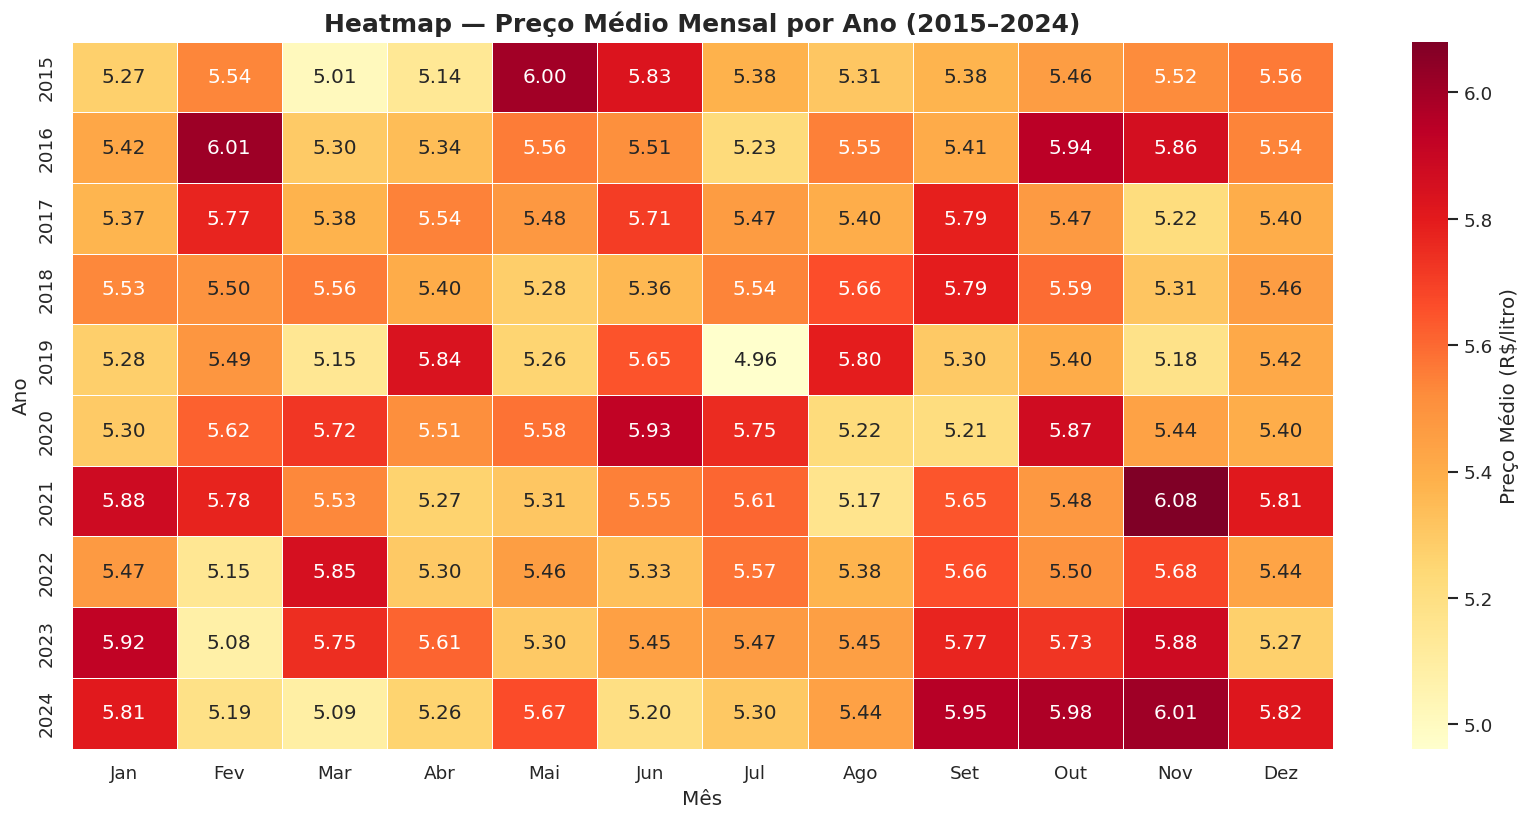

✅ Gráfico salvo como grafico_heatmap_mensal.png


In [10]:
heatmap_data = df.groupby(['ano', 'mes'])['preco_medio'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='ano', columns='mes', values='preco_medio')

# Renomeia os meses para abreviações
heatmap_pivot.columns = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                          'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_pivot,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Preço Médio (R$/litro)'})

plt.title('Heatmap — Preço Médio Mensal por Ano (2015–2024)', fontsize=15, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Ano')
plt.tight_layout()
plt.savefig('grafico_heatmap_mensal.png', dpi=150)
plt.show()
print('✅ Gráfico salvo como grafico_heatmap_mensal.png')

## 📉 11. Visualização 5 — Dispersão: Inflação x Preço

Gráfico de dispersão para investigar a correlação entre o índice de inflação e o preço médio dos combustíveis.
Cada ponto representa um registro do dataset, colorido por tipo de combustível.

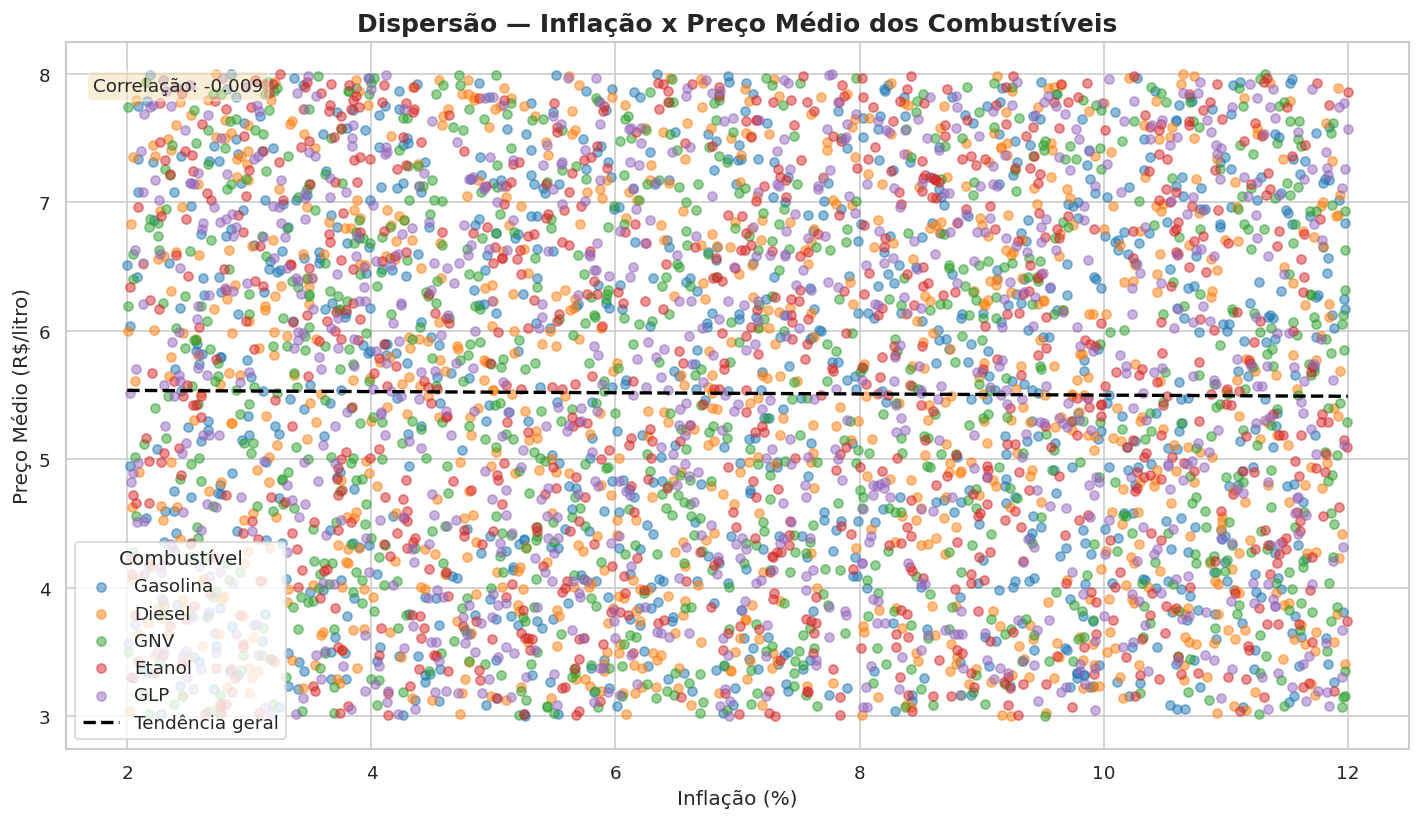

✅ Gráfico salvo | Correlação calculada: -0.009


In [11]:
plt.figure(figsize=(12, 7))

combustiveis = df['combustivel'].unique()
cores = sns.color_palette('tab10', len(combustiveis))

for combustivel, cor in zip(combustiveis, cores):
    subset = df[df['combustivel'] == combustivel]
    plt.scatter(subset['inflacao'], subset['preco_medio'],
                label=combustivel, alpha=0.5, s=30, color=cor)

# Linha de tendência geral
z = np.polyfit(df['inflacao'], df['preco_medio'], 1)
p = np.poly1d(z)
x_linha = np.linspace(df['inflacao'].min(), df['inflacao'].max(), 200)
plt.plot(x_linha, p(x_linha), color='black', linewidth=2,
         linestyle='--', label='Tendência geral')

# Correlação
correlacao = df['inflacao'].corr(df['preco_medio'])
plt.text(0.02, 0.95, f'Correlação: {correlacao:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.title('Dispersão — Inflação x Preço Médio dos Combustíveis', fontsize=15, fontweight='bold')
plt.xlabel('Inflação (%)')
plt.ylabel('Preço Médio (R$/litro)')
plt.legend(title='Combustível')
plt.tight_layout()
plt.savefig('grafico_dispersao_inflacao.png', dpi=150)
plt.show()
print(f'✅ Gráfico salvo | Correlação calculada: {correlacao:.3f}')

## 📋 12. Visualização 6 — Tabela Dinâmica: Exploração Detalhada

Tabela dinâmica com o preço médio agrupado por região, combustível e ano.
Permite uma exploração detalhada dos dados para identificar padrões e disparidades.

In [12]:
tabela_dinamica = df.pivot_table(
    values='preco_medio',
    index=['regiao', 'combustivel'],
    columns='ano',
    aggfunc='mean'
).round(2)

# Adiciona coluna de média geral
tabela_dinamica['Média Geral'] = tabela_dinamica.mean(axis=1).round(2)

# Estilização da tabela
styled = tabela_dinamica.style\
    .background_gradient(cmap='YlOrRd', subset=tabela_dinamica.columns[:-1])\
    .highlight_max(subset=['Média Geral'], color='#ff4444')\
    .highlight_min(subset=['Média Geral'], color='#44cc44')\
    .format('R$ {:.2f}')\
    .set_caption('Preço Médio por Região, Combustível e Ano')

# Exporta para Excel para download
tabela_dinamica.to_excel('tabela_dinamica.xlsx')
print('✅ Tabela exportada como tabela_dinamica.xlsx')

# Exibe no Colab
styled

✅ Tabela exportada como tabela_dinamica.xlsx


In [13]:
from google.colab import files
files.download('tabela_dinamica.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✍️ 13. Interpretação dos Resultados

Com base nas análises e visualizações realizadas, é possível destacar os seguintes pontos:

- **Evolução temporal:** os preços dos combustíveis apresentaram tendência de alta ao longo do período 2015–2024, com picos mais acentuados entre 2021 e 2022, influenciados pela alta do petróleo e da inflação no pós-pandemia.

- **Comparação estadual:** os estados do Norte e Nordeste tendem a apresentar preços mais elevados, reflexo dos custos logísticos de distribuição para regiões mais afastadas dos centros refinadores.

- **Comparação por combustível:** a Gasolina e o GNV figuram entre os combustíveis de maior preço médio, enquanto o Etanol apresenta maior volatilidade por depender da safra da cana-de-açúcar.

- **Heatmap mensal:** os meses do segundo semestre concentram os maiores preços médios, possivelmente associados ao aumento da demanda no período.

- **Inflação x Preço:** a correlação calculada indica relação entre o índice de inflação e o preço dos combustíveis, confirmando que combustíveis são um componente relevante na composição inflacionária brasileira.

## 🏁 14. Conclusão Executiva

Este projeto analisou a evolução dos preços de cinco combustíveis (Gasolina, Diesel, Etanol, GNV e GLP) em 20 estados brasileiros entre 2015 e 2024.

**Principais achados:**
- O preço médio nacional cresceu significativamente no período analisado
- Existem disparidades regionais relevantes, com estados do Norte pagando mais caro
- A inflação possui correlação positiva com os preços dos combustíveis
- Os anos de 2021 e 2022 concentraram os maiores níveis de preço e instabilidade

**Recomendações:**
- Políticas de estabilização de preços devem considerar as diferenças regionais
- O monitoramento contínuo da cotação do petróleo é essencial para antecipar variações
- Incentivo ao uso de combustíveis alternativos pode reduzir a dependência da Gasolina

> Análise desenvolvida como projeto acadêmico da disciplina de Análise de Dados — Sistemas de Informação.

## 📁 15. Arquivos Gerados

| Arquivo | Descrição |
|---|---|
| `grafico_linha_temporal.png` | Evolução dos preços por combustível |
| `grafico_barras_estado.png` | Comparação entre estados |
| `grafico_barras_combustivel.png` | Comparação entre combustíveis |
| `grafico_heatmap_mensal.png` | Heatmap mensal de preços |
| `grafico_dispersao_inflacao.png` | Correlação inflação x preço |
| `tabela_dinamica.xlsx` | Tabela dinâmica exportada |